# Multi-Pattern Gap Analysis

Loads `gap_multi_pattern_results.json` and produces figures:
1. CD_fc vs number of patterns trained (mean ± std across seeds), current vs long_warmup
2. Soft margin vs number of patterns
3. Accuracy vs number of patterns
4. Per-pattern CD heatmap (how each stored pattern's CD evolves as more patterns are added)

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

RESULTS_FILE = "../results/multi_pattern/gap_multi_pattern_results.json"

with open(RESULTS_FILE) as f:
    data = json.load(f)

cfg = data["config"]
results = data["results"]
max_patterns = cfg["max_patterns"]
print(f"Rules: {set(r['rule'] for r in results)}")
print(f"Seeds: {sorted(set(r['seed'] for r in results))}")
print(f"Max patterns: {max_patterns}")

Rules: {'current', 'long_warmup'}
Seeds: [0, 1, 2]
Max patterns: 10


In [3]:
def collect_metric(results, rule, metric):
    """Return array [n_seeds, max_patterns] where each entry is the mean across
    all patterns seen so far after training on pattern k."""
    rule_results = [r for r in results if r["rule"] == rule]
    out = []
    for r in rule_results:
        row = []
        for step in r["pattern_sequence"]:
            vals = list(step[metric].values())
            row.append(np.mean(vals))
        out.append(row)
    return np.array(out)  # [n_seeds, n_steps]

def collect_metric_per_pattern(results, rule, metric):
    """Return dict: pattern_idx -> array [n_seeds, n_steps_where_visible].
    step s is visible from pattern s onwards."""
    rule_results = [r for r in results if r["rule"] == rule]
    max_pat = max(len(r["pattern_sequence"]) for r in rule_results)
    per_pat = {}
    for pat_idx in range(max_pat):
        vals_by_seed = []
        for r in rule_results:
            seed_vals = []
            for step in r["pattern_sequence"]:
                if str(pat_idx) in step[metric]:
                    seed_vals.append(step[metric][str(pat_idx)])
            vals_by_seed.append(seed_vals)
        per_pat[pat_idx] = np.array(vals_by_seed)  # [n_seeds, n_visible_steps]
    return per_pat

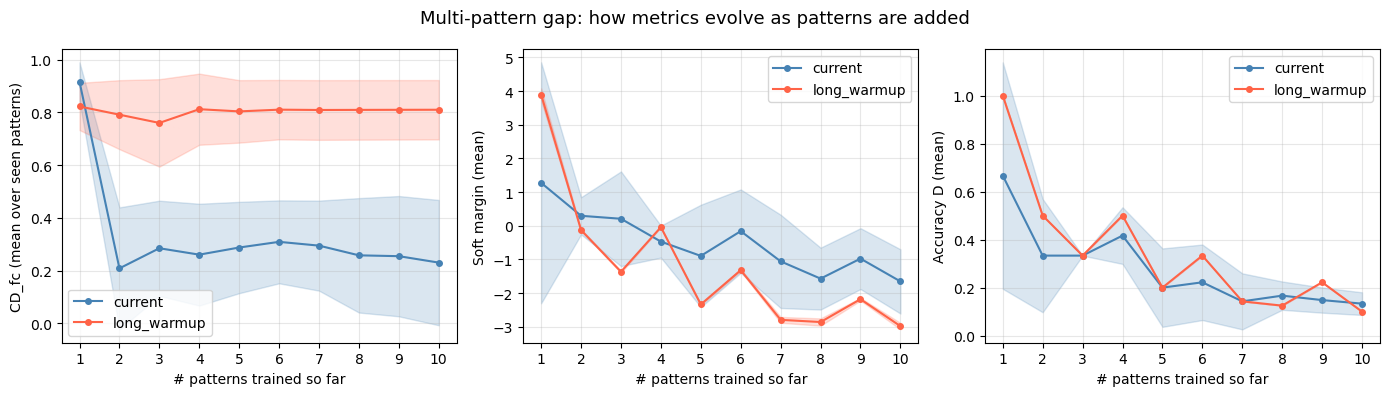

In [4]:
# Figure 1: Mean CD_fc vs number of patterns trained
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
rules = ["current", "long_warmup"]
colors = {"current": "steelblue", "long_warmup": "tomato"}
metrics = [
    ("final_CD_per_pattern", "CD_fc (mean over seen patterns)", axes[0]),
    ("final_margin_per_pattern", "Soft margin (mean)", axes[1]),
    ("final_acc_per_pattern", "Accuracy D (mean)", axes[2]),
]

for metric_key, ylabel, ax in metrics:
    for rule in rules:
        arr = collect_metric(results, rule, metric_key)  # [n_seeds, n_steps]
        if arr.size == 0:
            continue
        xs = np.arange(1, arr.shape[1] + 1)
        mean = arr.mean(axis=0)
        std = arr.std(axis=0)
        ax.plot(xs, mean, label=rule, color=colors[rule], marker="o", ms=4)
        ax.fill_between(xs, mean - std, mean + std, alpha=0.2, color=colors[rule])
    ax.set_xlabel("# patterns trained so far")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, max_patterns + 1))
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Multi-pattern gap: how metrics evolve as patterns are added", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/multi_pattern/gap_multi_pattern_fig1_overview.png", dpi=150, bbox_inches="tight")
plt.show()

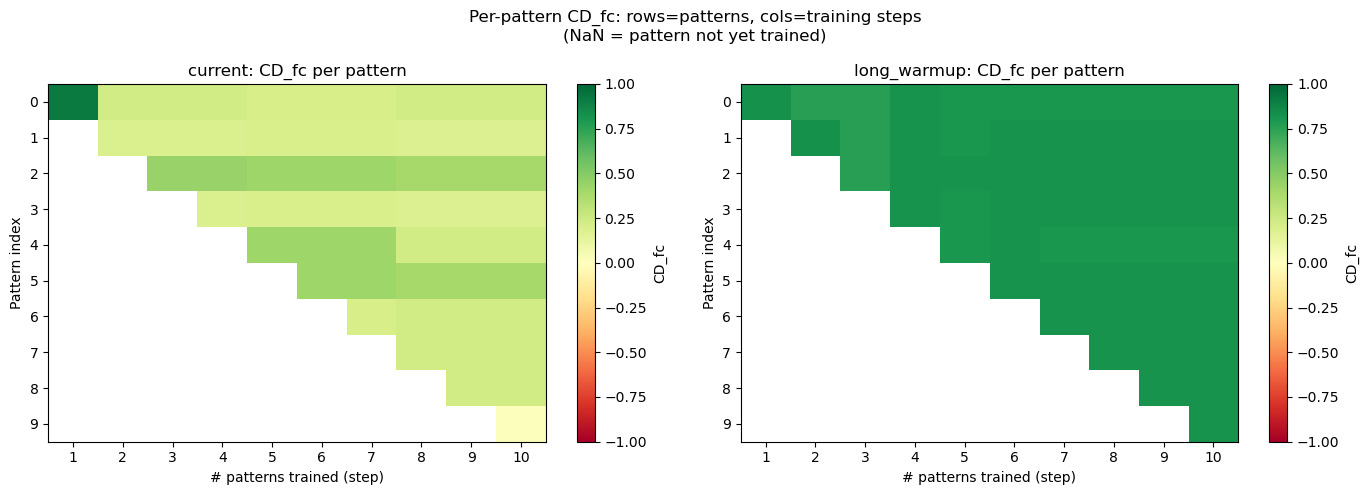

In [5]:
# Figure 2: Per-pattern CD heatmap — does CD degrade for earlier patterns?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, rule in zip(axes, rules):
    per_pat = collect_metric_per_pattern(results, rule, "final_CD_per_pattern")
    n_pats = max_patterns
    # Build matrix: row=pattern, col=step (NaN when not yet trained)
    mat = np.full((n_pats, n_pats), np.nan)
    for pat_idx, arr in per_pat.items():
        if arr.size == 0:
            continue
        mean_vals = arr.mean(axis=0)
        # pat_idx is visible from step pat_idx onwards
        for step_offset, val in enumerate(mean_vals):
            col = pat_idx + step_offset  # absolute step index
            if col < n_pats:
                mat[pat_idx, col] = val

    im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdYlGn", aspect="auto", origin="upper")
    ax.set_title(f"{rule}: CD_fc per pattern")
    ax.set_xlabel("# patterns trained (step)")
    ax.set_ylabel("Pattern index")
    ax.set_xticks(range(n_pats)); ax.set_xticklabels(range(1, n_pats + 1))
    ax.set_yticks(range(n_pats)); ax.set_yticklabels(range(n_pats))
    plt.colorbar(im, ax=ax, label="CD_fc")

fig.suptitle("Per-pattern CD_fc: rows=patterns, cols=training steps\n"
             "(NaN = pattern not yet trained)", fontsize=12)
plt.tight_layout()
plt.savefig("../figures/multi_pattern/gap_multi_pattern_fig2_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

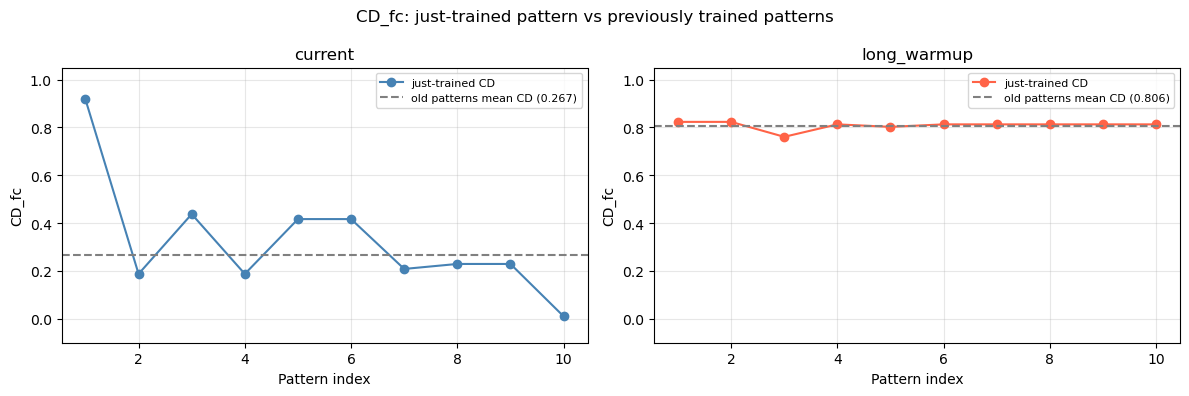

In [6]:
# Figure 3: CD gap for just-trained pattern (diagonal of heatmap) vs old patterns (off-diagonal)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, rule in zip(axes, rules):
    per_pat = collect_metric_per_pattern(results, rule, "final_CD_per_pattern")
    # "just-trained": CD measured immediately after training on that pattern
    just_trained, after_more = [], []
    for pat_idx, arr in per_pat.items():
        if arr.size == 0:
            continue
        # first element = measured right after training pattern pat_idx
        just_trained.append(arr.mean(axis=0)[0])
        # remaining elements = CD for this pattern while other patterns were trained
        if arr.shape[1] > 1:
            after_more.extend(arr.mean(axis=0)[1:].tolist())

    xs_jt = range(1, len(just_trained) + 1)
    ax.plot(xs_jt, just_trained, "o-", color=colors[rule], label="just-trained CD")
    ax.axhline(np.mean(after_more) if after_more else np.nan,
               color="gray", ls="--", label=f"old patterns mean CD ({np.mean(after_more):.3f})")
    ax.set_title(f"{rule}")
    ax.set_xlabel("Pattern index")
    ax.set_ylabel("CD_fc")
    ax.set_ylim(-0.1, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("CD_fc: just-trained pattern vs previously trained patterns", fontsize=12)
plt.tight_layout()
plt.savefig("../figures/multi_pattern/gap_multi_pattern_fig3_just_vs_old.png", dpi=150, bbox_inches="tight")
plt.show()